In [ ]:
#STEP 1 — Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

STEP 2 — Load Your Datasets

In [7]:
normal = pd.read_csv(r"C:\Users\happy\Desktop\SDPMODEL\normal.csv")
attack = pd.read_csv(r"C:\Users\happy\Desktop\SDPMODEL\attnor.csv")

print("Normal data shape:", normal.shape)
print("Attack data shape:", attack.shape)

Normal data shape: (954, 7)
Attack data shape: (976, 7)


STEP 3 — Check Dataset Columns

In [8]:
print("Normal dataset columns:")
print(normal.columns)

print("\nAttack dataset columns:")
print(attack.columns)

Normal dataset columns:
Index(['mote_id', 'time_window', 'PDR', 'control_msg_rate',
       'parent_change_rate', 'rank_change_rate', 'label'],
      dtype='object')

Attack dataset columns:
Index(['mote_id', 'time_window', 'PDR', 'control_msg_rate',
       'parent_change_rate', 'rank_change_rate', 'label'],
      dtype='object')


STEP 4 — Select Routing Stability Features

These represent the RSV (Routing Stability Vector).

In [9]:
#RSV (Routing Stability Vector)

features = [
    'rank_change_rate',
    'parent_change_rate',
    'control_msg_rate',
    'PDR'
]

X_train = normal[features]
X_test = attack[features]

STEP 5 — Training the Model (Normal Behaviour Learning)

In [10]:
model = IsolationForest(
    contamination=0.1,
    random_state=42
)

model.fit(X_train)

print("Model trained successfully")

Model trained successfully


STEP 6 — Detect Anomalies

0 = normal
1 = anomaly

In [11]:
attack['anomaly'] = model.predict(X_test)

# convert output
attack['anomaly'] = attack['anomaly'].map({1:0, -1:1})

print(attack[['anomaly']].head())

   anomaly
0        0
1        1
2        0
3        1
4        0


STEP 7 — Compute Anomaly Scores

In [12]:
attack['anomaly_score'] = model.decision_function(X_test)

print(attack[['anomaly_score']].head())

   anomaly_score
0       0.049706
1      -0.114784
2       0.056400
3      -0.114784
4       0.056400


STEP 8 — Intent Inference (Rule-Based)

In [13]:
def infer_intent(row):

    if row['rank_change_rate'] < -5:
        return "Traffic Attraction"

    elif row['parent_change_rate'] > 5:
        return "Topology Disruption"

    elif row['PDR'] < 0.5:
        return "Silent Packet Drop"

    elif row['control_msg_rate'] > 20:
        return "Resource Exhaustion"

    else:
        return "Normal"


attack['intent'] = attack.apply(infer_intent, axis=1)

print(attack[['intent']].head())

                intent
0               Normal
1  Topology Disruption
2               Normal
3  Topology Disruption
4               Normal


STEP 9 — Attack Containment Radius (ACR)

In [14]:
acr = attack[attack['anomaly'] == 1]['mote_id'].nunique()

print("Attack Containment Radius (ACR):", acr)

Attack Containment Radius (ACR): 15


STEP 10 — Evaluate Detection Performance

In [15]:
y_true = attack['label']
y_pred = attack['anomaly']

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.826844262295082
Precision: 0.8772378516624041
Recall: 0.7392241379310345
F1 Score: 0.8023391812865497


**STEP 11 — Visualize Anomaly Scores**

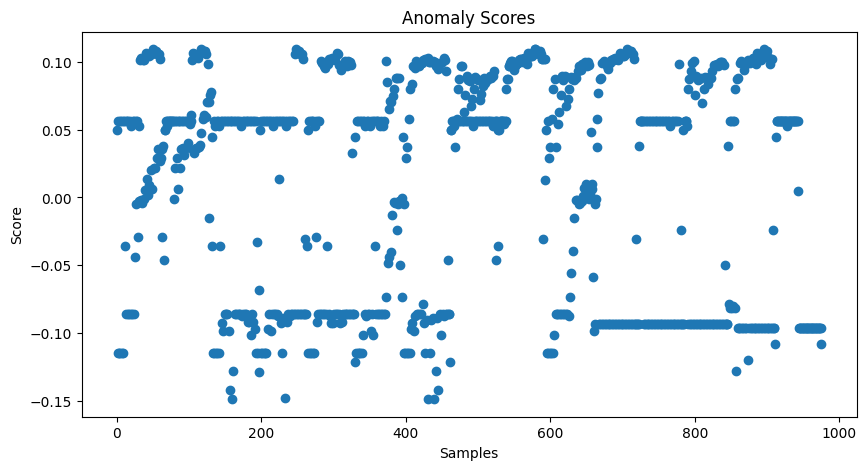

In [16]:
plt.figure(figsize=(10,5))

plt.scatter(
    attack.index,
    attack['anomaly_score']
)

plt.title("Anomaly Scores")
plt.xlabel("Samples")
plt.ylabel("Score")

plt.show()

In [17]:
attack.to_csv(
    r"C:\Users\happy\Desktop\SDPMODEL\final_results.csv",
    index=False
)

print("Results saved successfully")

Results saved successfully
